In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Clean-Data")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

In [2]:
series = df['total_power'].values
hist, _ = np.histogram(series, bins=30) #converted time series to probability distribution
prob = hist/np.sum(hist) #converting counts to probabilities
prob = prob[prob>0] #remove zero probabilities
entropy = -np.sum(prob*np.log2(prob))
print("Shannon Entropy:" ,entropy)

Shannon Entropy: 3.5212244335796674


In [3]:
series = df['total_power'].values
N = len(series)
mean_series = np.mean(series)
Y = np.cumsum(series-mean_series) #converted data into cumulative deviation series
R = np.max(Y)-np.min(Y) #Calculated Range
S = np.std(series)
hurst = np.log(R/S)/np.log(N)
print("Hurst Exponent:",hurst)

Hurst Exponent: 0.8634294280106173


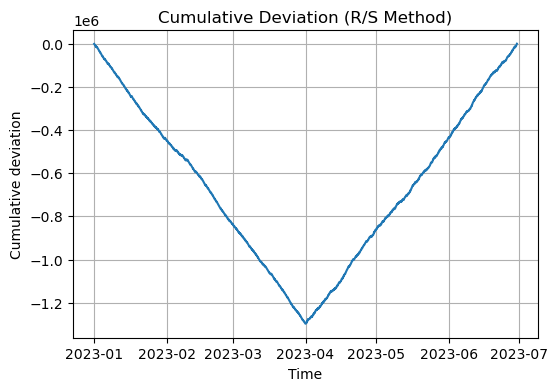

In [4]:
plt.figure(figsize=(6,4))
plt.plot(df.index, Y)
plt.title("Cumulative Deviation (R/S Method)")
plt.xlabel("Time")
plt.ylabel("Cumulative deviation")
plt.grid(True)
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler
X = df[['fridge','ac','lights','microwave']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

This section uses artificially injected anomalies only for evaluation purposes.

In [4]:
np.random.seed(42)
y_true = np.zeros(len(X_scaled))
anomaly_idx = np.random.choice(len(X_scaled), size=int(0.02*len(X_scaled)),replace=False)
X_scaled[anomaly_idx] = X_scaled[anomaly_idx]*3
y_true[anomaly_idx] = 1

In [5]:
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_true, test_size=0.3, random_state=42)
X_train_normal = X_train[y_train == 0]
model =  OneClassSVM(kernel='rbf',gamma=0.1,nu=0.02)
model.fit(X_train_normal)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,nu,0.02
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [6]:
y_pred = model.predict(X_test)
y_pred = np.where(y_pred==-1,1,0)

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
scores = model.decision_function(X_test)
auc = roc_auc_score(y_test,-scores)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("AUC:",auc)

Accuracy: 0.9144178874325366
Precision: 0.4365482233502538
Recall: 1.0
F1 Score: 0.607773851590106
AUC: 1.0


In [19]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

best_f1 = 0
best_params = {}
results = []

for nu in [0.01, 0.02, 0.03, 0.05]:
    for gamma in [0.001, 0.01, 0.1, 1]:
        
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train)
        
        y_pred = model.predict(X_test)
        y_pred = np.where(y_pred == -1, 1, 0)
        
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        
        results.append((nu, gamma, precision, recall, f1))
        
        if f1 > best_f1:
            best_f1 = f1
            best_params = {'nu': nu, 'gamma': gamma}

print("Best Params:", best_params)
print("Best F1 Score:", best_f1)

Best Params: {'nu': 0.01, 'gamma': 0.01}
Best F1 Score: 0.9608938547486033


In [10]:
from sklearn.linear_model import LinearRegression

# Shift the appliances by 1 hour (Use what happened at 4 PM to predict 5 PM)
df_baseline = df.copy()
df_baseline['fridge_lag1'] = df_baseline['fridge'].shift(1)
df_baseline['ac_lag1'] = df_baseline['ac'].shift(1)
df_baseline['lights_lag1'] = df_baseline['lights'].shift(1)
df_baseline['microwave_lag1'] = df_baseline['microwave'].shift(1)
df_baseline['total_lag1'] = df_baseline['total_power'].shift(1)

# Drop the first row which is now NaN
df_baseline = df_baseline.dropna()

In [11]:
#X is ONLY past data (Lags)
X_base = df_baseline[['fridge_lag1', 'ac_lag1', 'lights_lag1', 'microwave_lag1', 'total_lag1']]
y_base = df_baseline['total_power']

#Split Chronologically
train_size = int(len(df_baseline) * 0.8)
X_train_b, X_test_b = X_base.iloc[:train_size], X_base.iloc[train_size:]
y_train_b, y_test_b = y_base.iloc[:train_size], y_base.iloc[train_size:]

In [14]:
#Train Linear Regression Baseline
lr_model = LinearRegression()
lr_model.fit(X_train_b, y_train_b)

#Predict & Evaluate
y_pred_b = lr_model.predict(X_test_b)

rmse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
mae_b = mean_absolute_error(y_test_b, y_pred_b)
print(f"Baseline Linear Regression RMSE: {rmse_b:.2f}")
print(f"Baseline Linear Regression MAE: {mae_b:.2f}")

Baseline Linear Regression RMSE: 985.38
Baseline Linear Regression MAE: 825.01


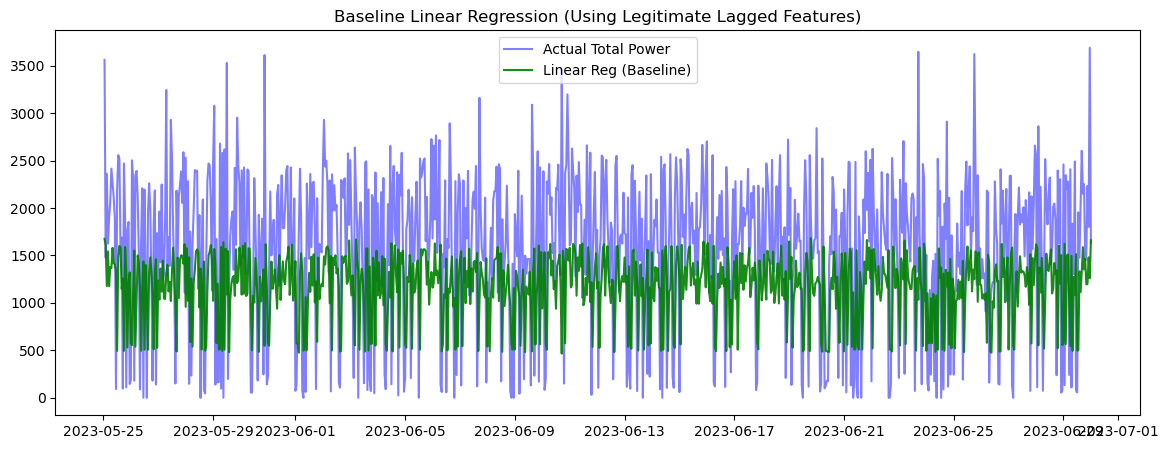

In [13]:
#Plotting
plt.figure(figsize=(14, 5))
plt.plot(y_test_b.index, y_test_b, label='Actual Total Power', color='blue', alpha=0.5)
plt.plot(y_test_b.index, y_pred_b, label='Linear Reg (Baseline)', color='green', alpha=0.9)
plt.title("Baseline Linear Regression (Using Legitimate Lagged Features)")
plt.legend()
plt.show()

In [2]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#Adding time features
df_features = df[['total_power']].copy()
df_features['hour'] = df_features.index.hour
df_features['day'] = df_features.index.dayofweek

#Scale all 3 features to (0, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_features)

In [3]:
#Create Sequences for all features
sequence_length = 24  
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    # X gets all 3 columns for the past 24 hours
    X.append(scaled_data[i-sequence_length:i, :]) 
    # y only gets the target column for the 25th hour
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

#Split Chronologically
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [4]:
#Build LSTM model
model = Sequential()
# Input shape is now (24, 3) because we have 3 features
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.1)) # Lower dropout so it doesn't over-smooth
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.1))
model.add(Dense(units=1)) 
model.compile(optimizer='adam', loss='mean_squared_error')

D:\Anaconda\envs\py310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
#Training the Model
print("Training Multivariate LSTM...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

#Predict
predictions = model.predict(X_test)

Training Multivariate LSTM...
Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0391 - val_loss: 0.0528
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0372 - val_loss: 0.0533
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0364 - val_loss: 0.0761
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0373 - val_loss: 0.0523
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0382 - val_loss: 0.0552
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0367 - val_loss: 0.0530
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0366 - val_loss: 0.0520
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0365 - val_loss: 0.0527
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0360 - val_loss: 0.0525
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0358 - val_loss: 0.0538
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0360 - val_loss: 0.0520
Epoch 12/50
97/97 ━━━━━━━━━━━━━━━

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
dummy_array = np.zeros((len(predictions), 3))
dummy_array[:, 0] = predictions[:, 0]
predictions_real = scaler.inverse_transform(dummy_array)[:, 0]
dummy_array_y = np.zeros((len(y_test), 3))
dummy_array_y[:, 0] = y_test
y_test_real = scaler.inverse_transform(dummy_array_y)[:, 0]

#Evaluate Metrics
rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
mae = mean_absolute_error(y_test_real, predictions_real)
print(f"\nLSTM RMSE: {rmse:.2f}")
print(f"LSTM MAE: {mae:.2f}")


LSTM RMSE: 815.11
LSTM MAE: 647.34


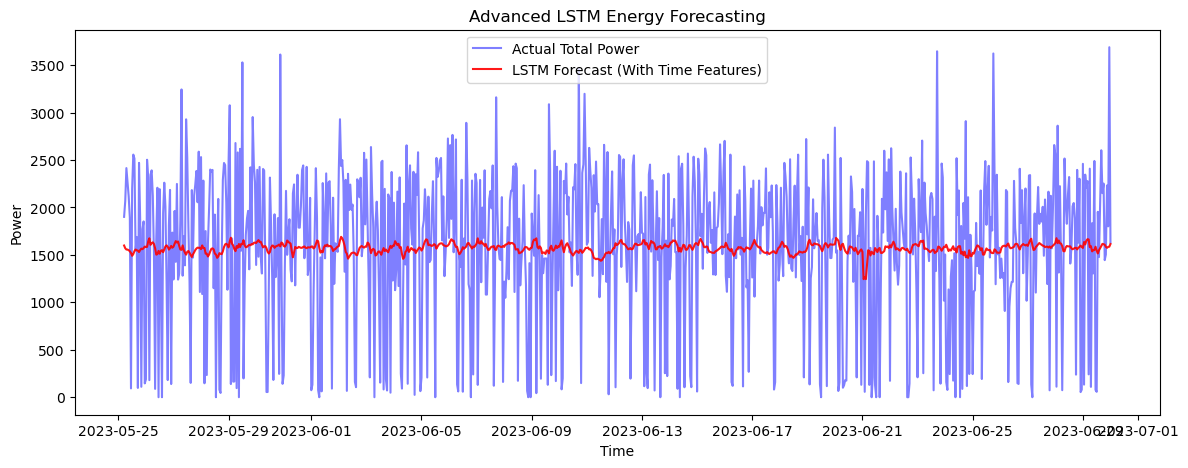

In [8]:
#Plotting
plt.figure(figsize=(14, 5))
test_indices = df.index[sequence_length + train_size:]
plt.plot(test_indices, y_test_real, label='Actual Total Power', color='blue', alpha=0.5)
plt.plot(test_indices, predictions_real, label='LSTM Forecast (With Time Features)', color='red', alpha=0.9)
plt.title("Advanced LSTM Energy Forecasting")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()